# **Data Preparation**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
raw_data = pd.read_csv('insurance.csv')
# Display the first few rows of the dataset
print(raw_data.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
# Data Manipulation
# Check for missing values
print(raw_data.isnull().sum())
# Remove duplicates
clean_data = raw_data.drop_duplicates()
# Summary statistics
print(raw_data.describe())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [4]:
# Numerical vs Categorical Data
num_cols = raw_data.select_dtypes(include=['float64', 'int64']).columns
uniq_num_values = raw_data[num_cols].nunique()

cat_cols = raw_data.select_dtypes(include=['object']).columns
uniq_cat_values = raw_data[cat_cols].nunique()

print("Numerical Columns:")
for col in num_cols:
    print(f"{col}: {uniq_num_values[col]}")
print("-" * 30 )
print("Categorical Columns:")
for col in cat_cols:
    print(f"{col}: {uniq_cat_values[col]} unique values ({clean_data[col].unique()})")

Numerical Columns:
age: 47
bmi: 548
children: 6
charges: 1337
------------------------------
Categorical Columns:
sex: 2 unique values (['female' 'male'])
smoker: 2 unique values (['yes' 'no'])
region: 4 unique values (['southwest' 'southeast' 'northwest' 'northeast'])


## **Data Exploration**

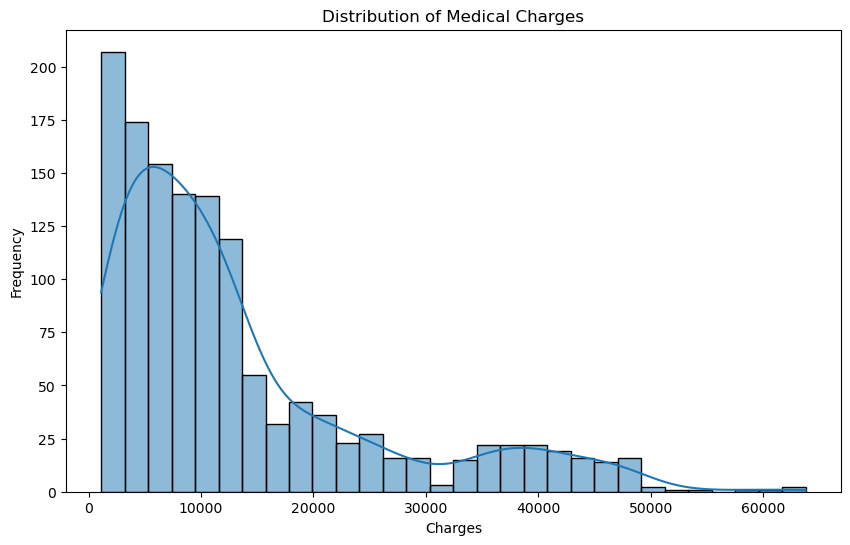

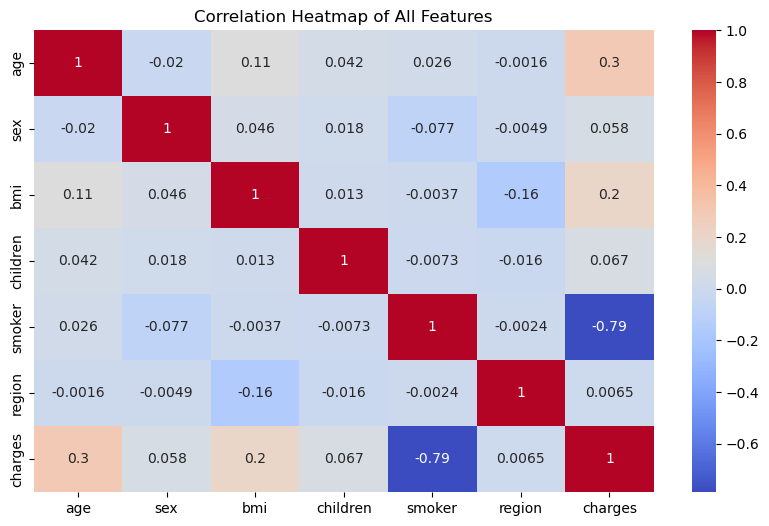

In [5]:
# Visualization
# Distribution of charges
plt.figure(figsize=(10, 6))
sns.histplot(clean_data['charges'], bins=30, kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# Correlation between all features and charges
plt.figure(figsize=(10, 6))
# Create a copy with encoded categorical variables
encoded_data = clean_data.copy()
encoded_data['sex'] = pd.factorize(encoded_data['sex'])[0]
encoded_data['smoker'] = pd.factorize(encoded_data['smoker'])[0]
encoded_data['region'] = pd.factorize(encoded_data['region'])[0]
sns.heatmap(encoded_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of All Features')
plt.show()

##### *Insights*
- The data is dominantly right-skewed so this analysis will apply log transformation to mitigate distractions for models
- There is a relatetively high positive correlation between age/charges and charges
- Whether the patient smokes or not is negatively associated with charges
- Less obvious correlations (+ to -): age & bmi, bmi & region, sex & smoker

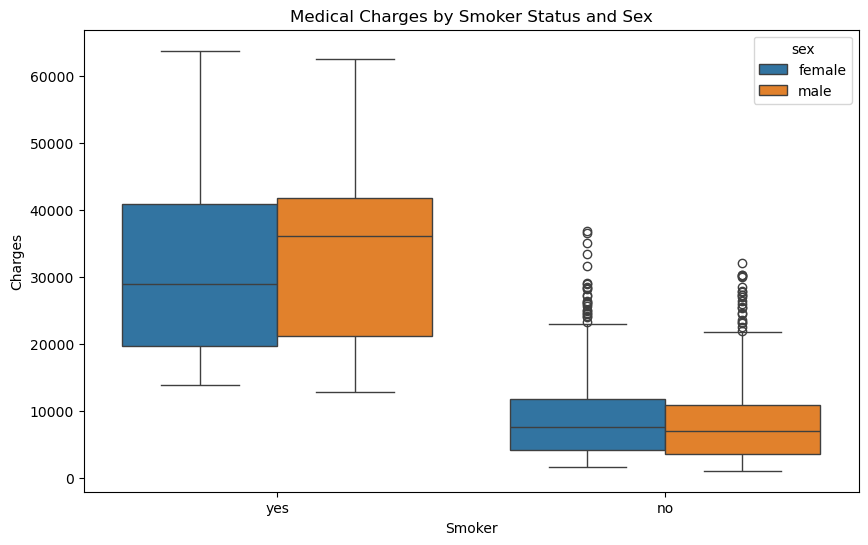

C:\Users\linhk\AppData\Local\Temp\ipykernel_32988\2454595370.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['bmi_tier']=pd.qcut(clean_data['bmi'], q=3, labels=['Low', 'Medium', 'High'])


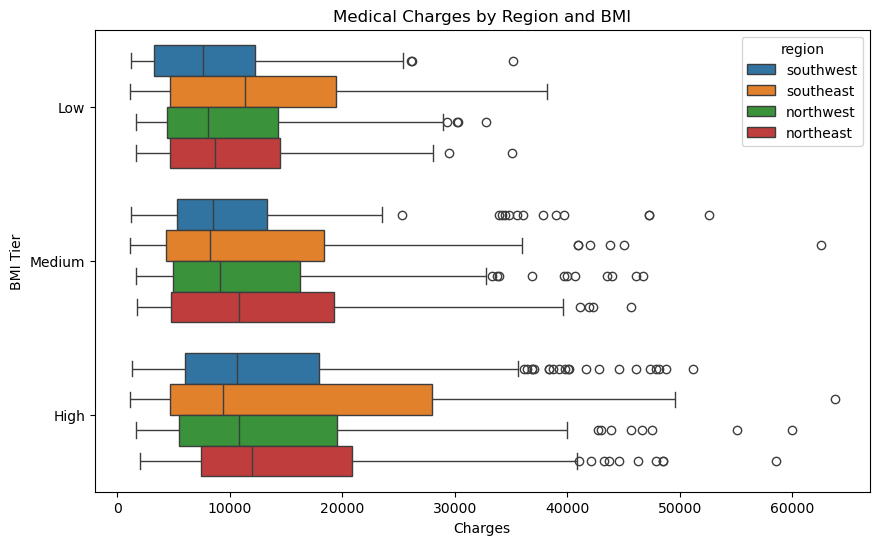

In [40]:
# Charges by smoker status and sex
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', hue='sex', data=clean_data)
plt.title('Medical Charges by Smoker Status and Sex')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

# Charges by region and bmi
clean_data['bmi_tier']=pd.qcut(clean_data['bmi'], q=3, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(10, 6))
sns.boxplot(y='bmi_tier', x='charges', hue='region', data=clean_data)
plt.title('Medical Charges by Region and BMI')
plt.xlabel('Charges')
plt.ylabel('BMI Tier')
plt.show()


##### *Remarks*:
Smoking & Gender: Tobacco use remains the primary driver of extreme medical costs. Among smokers, male patients incur notably higher median charges than female patients. Conversely, for non-smokers, medical expenses remain low and uniform regardless of sex.
<br>
BMI & Regional Volatility: Generally, higher BMI tiers correspond with an increased frequency of extreme high-cost outliers across all geographical regions. Interestingly, within the High BMI tier, the Southeast region exhibits an exceptionally wide interquartile spread, capturing both low-cost baselines and an extended upper-quartile cost distribution that surpasses other regions.

# **Training Classification and Regression Models**

In [7]:
# Importing libraries for modeling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
!pip install catboost
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [8]:
import numpy as np
# Evaluation Metrics
def evaluator(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

## ***Classification Models - Identifying Medical Risks***

In [9]:
# Define thresholds for charge tiers (Low, Medium, High)
low_threshold = clean_data['charges'].quantile(0.50)
high_threshold = clean_data['charges'].quantile(0.80)
# Map charges to risk tiers
def map_to_risk_tier(charge):
    if charge <= low_threshold:
        return 0  # Low Risk
    elif charge <= high_threshold:
        return 1  # Medium Risk
    else:
        return 2  # High Risk
# New target variable for classification
clean_data_clf = clean_data.copy()
clean_data_clf['risk_tier'] = clean_data_clf['charges'].apply(map_to_risk_tier)
clean_data_clf=clean_data_clf.drop(columns=['charges','bmi_tier'],axis=1)

In [10]:
# Importing libraries for classification models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

# Separate features (X) and our new classification target (y)
X_clf = clean_data_clf.drop(columns=['risk_tier'])
y_clf = clean_data_clf['risk_tier']
from sklearn.model_selection import train_test_split

# Training and testing data for classification
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Define columns by data type
num_cols = X_clf.select_dtypes(exclude=['object']).columns
cat_cols = X_clf.select_dtypes(include=['object']).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor_clf = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_cols),
        ("StandardScaler", numeric_transformer, num_cols)
    ]
)

# Preprocess the features
X_clf_train = preprocessor_clf.fit_transform(X_clf_train)
X_clf_test = preprocessor_clf.transform(X_clf_test)

In [11]:
# Initializing the classifier for multi-class classification
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss')

# Fitting the models
xgb_clf.fit(X_clf_train, y_clf_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
# Get predictions
y_clf_pred = xgb_clf.predict(X_clf_test)
# Evaluationmetrics for classification
print("Classification Report:")
print(classification_report(y_clf_test, y_clf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_clf_test, y_clf_pred))
print("Accuracy Score:", accuracy_score(y_clf_test, y_clf_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       134
           1       0.91      0.89      0.90        80
           2       0.94      0.83      0.88        54

    accuracy                           0.93       268
   macro avg       0.93      0.90      0.91       268
weighted avg       0.93      0.93      0.93       268

Confusion Matrix:
[[133   1   0]
 [  6  71   3]
 [  3   6  45]]
Accuracy Score: 0.9291044776119403


================ Classification Report ================
              precision    recall  f1-score   support

    Low Risk       0.94      0.99      0.96       134
 Medium Risk       0.91      0.89      0.90        80
   High Risk       0.94      0.83      0.88        54

    accuracy                           0.93       268
   macro avg       0.93      0.90      0.91       268
weighted avg       0.93      0.93      0.93       268



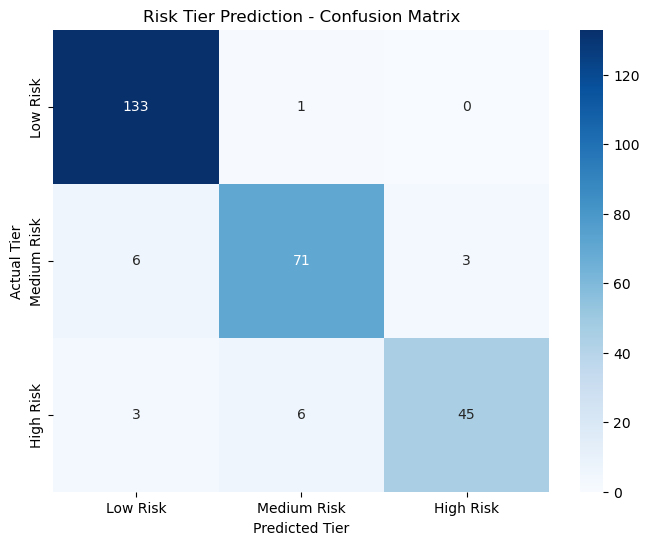

In [13]:
# Get predictions
y_pred = xgb_clf.predict(X_clf_test)

# Print metrics summary
print("================ Classification Report ================")
print(classification_report(y_clf_test, y_pred, target_names=['Low Risk', 'Medium Risk', 'High Risk']))

# Plot Confusion Matrix
cm = confusion_matrix(y_clf_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Risk', 'Medium Risk', 'High Risk'],
            yticklabels=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Risk Tier Prediction - Confusion Matrix')
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.show()

##### *Insights*
The model achieves a 94% High-Risk Precision (45 out of 48 high-risk individuals), thereby will likely flag high-risk patients correctly. Additionally, the 99% Low-Risk Recall rate (133 out of 134 low-risk individuals) ensures that patients classified as low-risk will not end up claiming expensive insurance benefits.

In [34]:
# Classify a new patient
new_patient_clf = pd.DataFrame({
    'age': [45],
    'sex': ['male'],
    'bmi': [29],
    'children': [2],
    'smoker': ['yes'],
    'region': ['southeast']
})
# Preprocess the new patient data
new_patient_clf_processed = preprocessor_clf.transform(new_patient_clf)
# Predict the risk tier for the new patient
predicted_tier = xgb_clf.predict(new_patient_processed)
tier_mapping = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
print(f"Predicted Risk tier for the new patient: {tier_mapping[predicted_tier[0]]}")

Predicted Risk tier for the new patient: High Risk


## ***Linear Regression Models - Predicting Medical Costs***

In [22]:
# Data Preparation for Prediction Modeling
X_rg = clean_data.drop(columns=['charges','bmi_tier'],axis=1)
y_rg = clean_data['charges']

# Define columns by data type
num_features = X_rg.select_dtypes(exclude="object").columns
cat_features = X_rg.select_dtypes(include="object").columns

preprocessor_rg = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)


X_rg = preprocessor_rg.fit_transform(X_rg)


X_rg.shape

# Using log transformation to reduce skewness in the target variable
y_rg = np.log1p(y_rg)


In [23]:
# Split Data into Train-Test Sets
X_rg_train, X_rg_test, y_rg_train, y_rg_test = train_test_split(X_rg, y_rg, test_size=0.2, random_state=42)
X_rg_train.shape, X_rg_test.shape

((1069, 11), (268, 11))

In [24]:
# Modeling
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_rg_train, y_rg_train) # Train models

    # Make predictions
    y_rg_train_pred = model.predict(X_rg_train)
    y_rg_test_pred = model.predict(X_rg_test)

    # Evaluate Train and Test Dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluator(y_rg_train, y_rg_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluator(y_rg_test, y_rg_test_pred)

    results.append({

        'Model Name': name,

        'R2 Score of Train Set': model_train_r2,

        'R2 Score of Test Set': model_test_r2

    })


    print(name)

    print('Model performance for Training dataset:')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))
    print('------------------------------------------')
    print('Model performance for Test dataset:')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training dataset:
- Root Mean Squared Error: 0.4535
- Mean Absolute Error: 0.2844
- R2 Score: 0.7497
------------------------------------------
Model performance for Test dataset:
- Root Mean Squared Error: 0.3978
- Mean Absolute Error: 0.2607
- R2 Score: 0.8295


Lasso
Model performance for Training dataset:
- Root Mean Squared Error: 0.9064
- Mean Absolute Error: 0.7327
- R2 Score: 0.0000
------------------------------------------
Model performance for Test dataset:
- Root Mean Squared Error: 0.9642
- Mean Absolute Error: 0.7765
- R2 Score: -0.0019


Ridge
Model performance for Training dataset:
- Root Mean Squared Error: 0.4535
- Mean Absolute Error: 0.2846
- R2 Score: 0.7496
------------------------------------------
Model performance for Test dataset:
- Root Mean Squared Error: 0.3980
- Mean Absolute Error: 0.2611
- R2 Score: 0.8293


K-Neighbors Regressor
Model performance for Training dataset:
- Root Mean Squared Error: 0.3702
- Mean Absol

In [25]:
# Results
pd.DataFrame(results).sort_values(by="R2 Score of Test Set", ascending=False)

,Model Name,R2 Score of Train Set,R2 Score of Test Set
7,CatBoosting Regressor,0.944678,0.858912
5,Random Forest Regressor,0.972778,0.855577
0,Linear Regression,0.749653,0.829479
2,Ridge,0.749649,0.829284
3,K-Neighbors Regressor,0.833196,0.804661
6,XGBRegressor,0.995320,0.800631
8,AdaBoost Regressor,0.707903,0.752537
4,Decision Tree,1.000000,0.714542
1,Lasso,0.000000,-0.001853


In [26]:
# Examining the best model (Cat Boosting Regressor)
coef = models['CatBoosting Regressor'].feature_importances_
feature_names = preprocessor_rg.get_feature_names_out()
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coef})
feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,OneHotEncoder__smoker_no,27.079530
3,OneHotEncoder__smoker_yes,26.846373
8,StandardScaler__age,26.280255
9,StandardScaler__bmi,8.489147
10,StandardScaler__children,6.229412
1,OneHotEncoder__sex_male,1.062289
5,OneHotEncoder__region_northwest,0.993605
4,OneHotEncoder__region_northeast,0.949463
0,OneHotEncoder__sex_female,0.743005
6,OneHotEncoder__region_southeast,0.683124


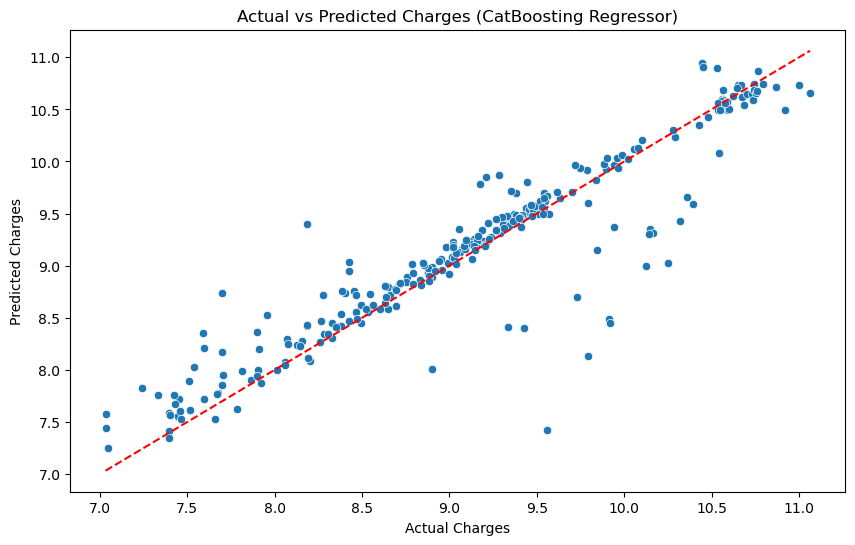

In [27]:
# Plotting predicted vs actual values for the best model
best_model = models['CatBoosting Regressor']
y_pred = best_model.predict(X_rg_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_rg_test, y=y_pred)
plt.plot([y_rg_test.min(), y_rg_test.max()], [y_rg_test.min(), y_rg_test.max()], 'r--')  # Line for perfect predictions
plt.title('Actual vs Predicted Charges (CatBoosting Regressor)')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.show()

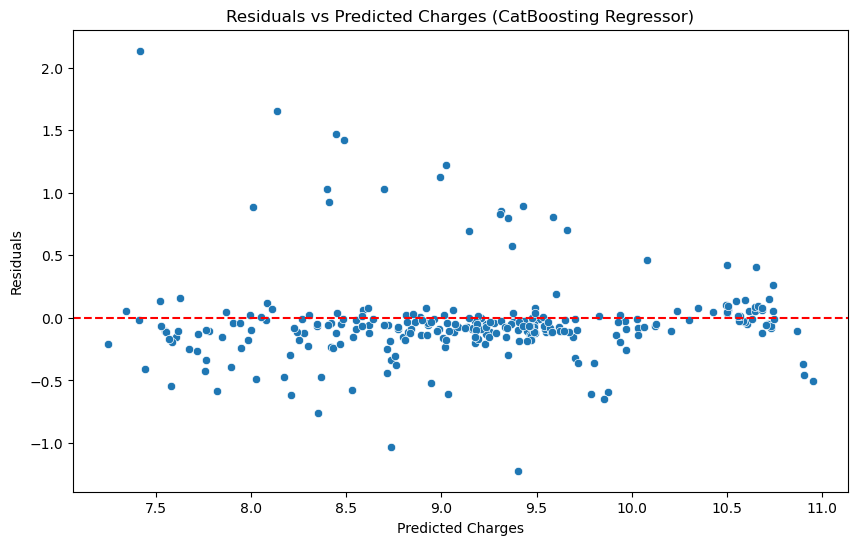

In [28]:
# Plotting residuals for the best model
residuals = y_rg_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Charges (CatBoosting Regressor)')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.show()

In [33]:
# Predicting charges for a new patient using the best model
new_patient_rg = pd.DataFrame({
    'age': [45],
    'sex': ['male'],
    'bmi': [29],
    'children': [2],
    'smoker': ['no'],
    'region': ['southeast']
})
# Preprocess the new patient data
new_patient_rg_processed = preprocessor_rg.transform(new_patient_rg)
# Predict the charges for the new patient
predicted_charge_log = best_model.predict(new_patient_rg_processed)
predicted_charge = np.expm1(predicted_charge_log)  # Inverse of log1p
print(f"Predicted Medical Charges for the new patient: ${predicted_charge[0]:.2f}")

Predicted Medical Charges for the new patient: $8311.11
